<a href="https://colab.research.google.com/github/oyaon/ML-Dengue-Prediction/blob/main/Dhaka_climateandDengueCorrelation_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Dhaka_Weather_Case_2022-2024 - Sheet1.csv')

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Step 1: Skip to main content
Untitled2.ipynb
Untitled2.ipynb_

[2]
0s
import pandas as pd

# Load the dataset
df = pd.read_csv('Dhaka_Weather_Case_2022-2024 - Sheet1.csv')

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Step 1: Scale Humidity
df['Humidity_corrected'] = df['Humidity'] * 10

Invalid entries after scaling: 897
Percentage invalid: 81.84%
Too many invalid entries. Humidity columns removed.
Skipping humidity validation - column removed

Final dataset columns: ['Date', 'TempMax', 'TempMin', 'Rainfall', 'Cases']

[3]
0s
# Add temporal features
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Season'] = df['Month'].apply(lambda x: 'Monsoon' if 6<=x<=9 else ('Winter' if x<=2 else 'Pre-Monsoon'))

# Create rainfall lag variables (2-4 week lags for mosquito breeding cycle)
for lag in [14, 21, 28]:  # 2, 3, 4 weeks
    df[f'Rainfall_lag_{lag}d'] = df['Rainfall'].shift(lag)

# 7-day rolling averages for temperature
df['TempMax_rolling7'] = df['TempMax'].rolling(7).mean()
df['TempMin_rolling7'] = df['TempMin'].rolling(7).mean()

[5]
4s
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
corr_matrix = df[['Cases', 'TempMax', 'TempMin', 'Rainfall',
                'Rainfall_lag_14d', 'Rainfall_lag_21d']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Dengue Case Correlations")


[6]
2s
fig, ax = plt.subplots(3,1, figsize=(14,12))
sns.lineplot(data=df, x='Date', y='Cases', ax=ax[0], color='red')
ax[0].set_title('Dengue Cases Over Time')

sns.lineplot(data=df, x='Date', y='TempMax', ax=ax[1], color='orange')
ax[1].set_title('Max Temperature')

sns.lineplot(data=df, x='Date', y='Rainfall', ax=ax[2], color='blue')
ax[2].set_title('Rainfall')
plt.tight_layout()


[7]
0s
lags = range(7, 35)  # 1-5 weeks
correlations = [df['Cases'].corr(df['Rainfall'].shift(lag)) for lag in lags]

plt.figure(figsize=(10,4))
plt.plot(lags, correlations)
plt.axvline(x=21, color='red', linestyle='--')  # 3-week lag
plt.xlabel('Lag (days)')
plt.ylabel('Correlation with Dengue Cases')
plt.title('Rainfall Lag Effect')

Colab paid products - Cancel contracts here

  0s
completed at 12:00 AM
Scale Humidity
df['Humidity_corrected'] = df['Humidity'] * 10

# Step 2: Identify Invalid Values
invalid_entries = df[df['Humidity_corrected'] > 100]
invalid_percentage = len(invalid_entries)/len(df) * 100

print(f"Invalid entries after scaling: {len(invalid_entries)}")
print(f"Percentage invalid: {invalid_percentage:.2f}%")

# Step 3: Handle Invalid Values
if invalid_percentage < 5:
    df['Humidity_corrected'] = df['Humidity_corrected'].clip(upper=100)
    print("Capped outliers at 100% humidity")
else:
    print("Too many invalid entries. Humidity columns removed.")
    df = df.drop(columns=['Humidity', 'Humidity_corrected'])

# Step 4: Validation (only if humidity exists)
if 'Humidity_corrected' in df.columns:
    external_validation_data = {
        '2022-01-01': 85,
        '2022-07-15': 92,
    }

    for date_str, real_humidity in external_validation_data.items():
        date = pd.to_datetime(date_str)
        if date in df['Date'].values:
            corrected_value = df.loc[df['Date'] == date, 'Humidity_corrected'].values[0]
            error = abs(corrected_value - real_humidity)
            print(f"{date_str}: Corrected={corrected_value} | Real={real_humidity} | Error={error:.1f}%")
else:
    print("Skipping humidity validation - column removed")

# Step 5: Final Output
if 'Humidity_corrected' in df.columns:
    print("\nUsing corrected humidity:")
    print(df[['Date', 'Humidity_corrected']].head())
else:
    print("\nFinal dataset columns:", df.columns.tolist())

# Export cleaned data
df.to_csv('Dhaka_Weather_Case_Cleaned.csv', index=False)

Invalid entries after scaling: 897
Percentage invalid: 81.84%
Too many invalid entries. Humidity columns removed.
Skipping humidity validation - column removed

Final dataset columns: ['Date', 'TempMax', 'TempMin', 'Rainfall', 'Cases']


In [3]:
# Add temporal features
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Season'] = df['Month'].apply(lambda x: 'Monsoon' if 6<=x<=9 else ('Winter' if x<=2 else 'Pre-Monsoon'))

# Create rainfall lag variables (2-4 week lags for mosquito breeding cycle)
for lag in [14, 21, 28]:  # 2, 3, 4 weeks
    df[f'Rainfall_lag_{lag}d'] = df['Rainfall'].shift(lag)

# 7-day rolling averages for temperature
df['TempMax_rolling7'] = df['TempMax'].rolling(7).mean()
df['TempMin_rolling7'] = df['TempMin'].rolling(7).mean()

Text(0.5, 1.0, 'Dengue Case Correlations')

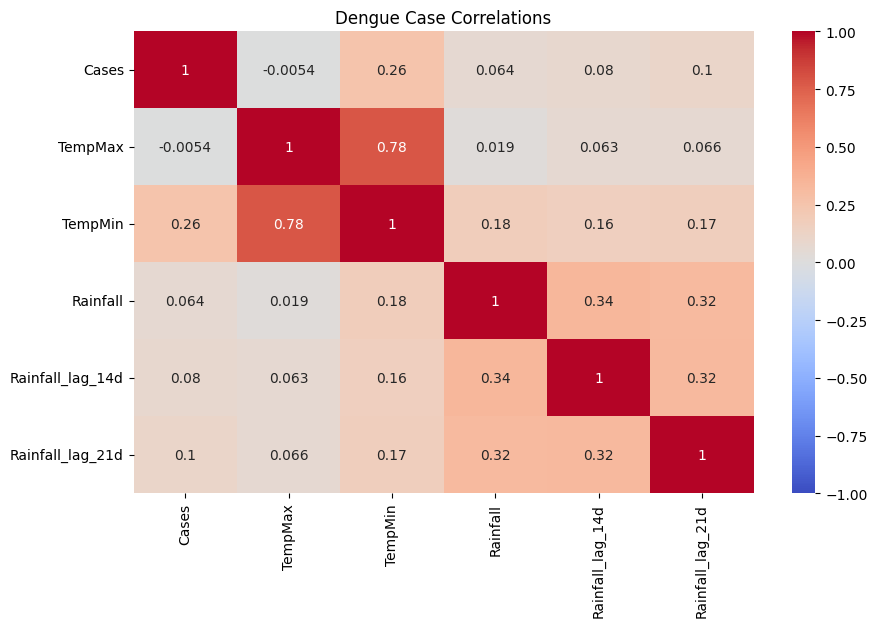

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
corr_matrix = df[['Cases', 'TempMax', 'TempMin', 'Rainfall',
                'Rainfall_lag_14d', 'Rainfall_lag_21d']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Dengue Case Correlations")

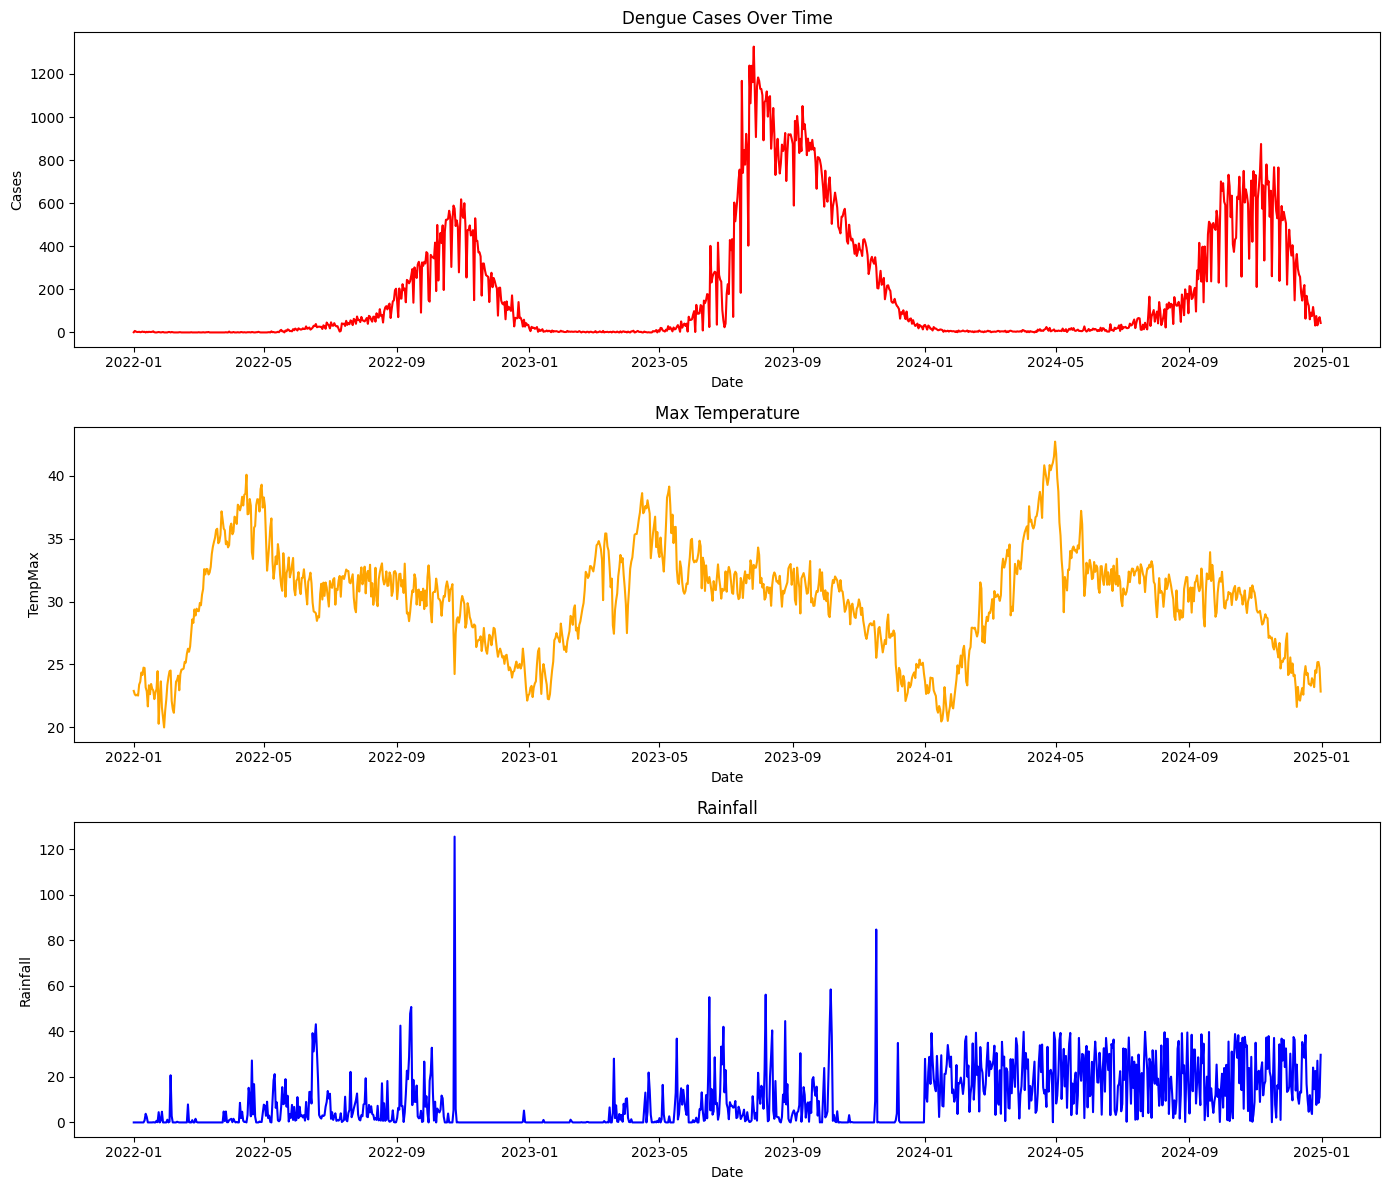

In [6]:
fig, ax = plt.subplots(3,1, figsize=(14,12))
sns.lineplot(data=df, x='Date', y='Cases', ax=ax[0], color='red')
ax[0].set_title('Dengue Cases Over Time')

sns.lineplot(data=df, x='Date', y='TempMax', ax=ax[1], color='orange')
ax[1].set_title('Max Temperature')

sns.lineplot(data=df, x='Date', y='Rainfall', ax=ax[2], color='blue')
ax[2].set_title('Rainfall')
plt.tight_layout()

Text(0.5, 1.0, 'Rainfall Lag Effect')

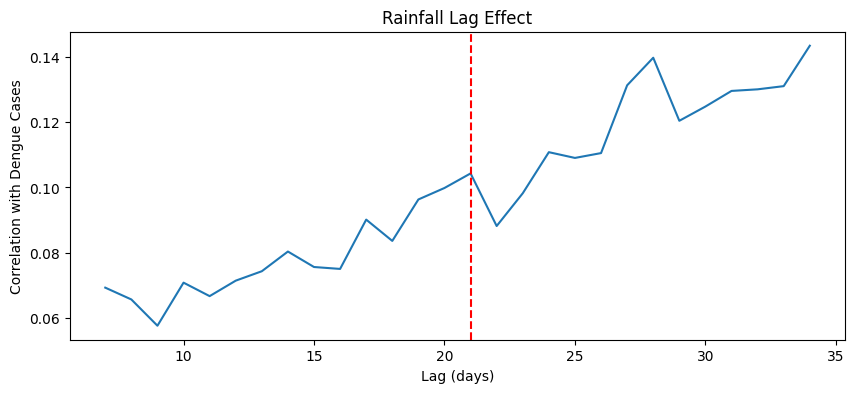

In [7]:
lags = range(7, 35)  # 1-5 weeks
correlations = [df['Cases'].corr(df['Rainfall'].shift(lag)) for lag in lags]

plt.figure(figsize=(10,4))
plt.plot(lags, correlations)
plt.axvline(x=21, color='red', linestyle='--')  # 3-week lag
plt.xlabel('Lag (days)')
plt.ylabel('Correlation with Dengue Cases')
plt.title('Rainfall Lag Effect')

In [24]:
# Export cleaned data
df.to_csv('Dhaka_Weather_Case_Cleaned.csv', index=False)